In [1]:
# This notebook tries to merge tiles into a specific mgrs tile. 
# will try to take into account overlapping issues. 
# the starting poit will be metric bursts. 
# the goal output will be merged mgrs tiles.

In [2]:
import geopandas as gpd
import contextily as ctx
import rasterio
from rasterio.crs import CRS
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from pathlib import Path
from dem_stitcher.rio_tools import reproject_profile_to_new_crs, reproject_arr_to_match_profile
from matplotlib.colors import ListedColormap
from shapely.geometry import box, Polygon, Point
from pyproj import Transformer
import shutil

In [ ]:
METRIC_BURST_DIR = Path('out/los-angeles-fire/metrics/track64')
METRIC_BURST_DIR, METRIC_BURST_DIR.exists()

(PosixPath('out/los-angeles-fire/metrics/track64'), True)

In [4]:
# metric paths
metric_burst_paths = sorted(list(METRIC_BURST_DIR.glob('*/transformer*.tif')))
metric_burst_paths

[PosixPath('out/los-angeles-fire/metrics/track64/T064-135514-IW1/transformer_T064-135514-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135515-IW1/transformer_T064-135515-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135516-IW1/transformer_T064-135516-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135516-IW2/transformer_T064-135516-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135517-IW1/transformer_T064-135517-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135517-IW2/transformer_T064-135517-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135518-IW1/transformer_T064-135518-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135518-IW2/transformer_T064-135518-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135519-IW1/transformer_T064-135519-IW1_2025-01-09.tif'),
 

In [5]:
# Use MGRS tile table to first find the corresponding MGRS tile.
# then use the information of the MGRS tile to merge the metric bursts.
df_mgrs = gpd.read_parquet('software/dist-s1-enumerator/src/dist_s1_enumerator/data/mgrs.parquet')
df_mgrs.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBF,32701,"MULTIPOLYGON(((199980 4600000,199980 4490200,3...","MULTIPOLYGON (((-179.58653 -48.72398, -179.638..."
2,01GBH,32701,"MULTIPOLYGON(((199980 4800040,199980 4690240,3...","MULTIPOLYGON (((-179.49865 -46.92590, -179.545..."
3,01GDM,32701,"MULTIPOLYGON(((399960 5200000,399960 5090200,5...","POLYGON ((-178.23431 -43.34619, -178.25485 -44..."
4,01GEL,32701,"MULTIPOLYGON(((499980 5100040,499980 4990240,6...","POLYGON ((-177.00025 -44.25288, -177.00025 -45..."


In [6]:
df_burst = gpd.read_parquet('software/dist-s1-enumerator/src/dist_s1_enumerator/data/jpl_burst_geo.parquet')
df_burst.head()

,jpl_burst_id,geometry
0,T001-000025-IW3,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4...."
1,T001-000026-IW2,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3...."
2,T001-000026-IW3,"POLYGON ((3.99185 5.35497, 4.70037 5.49605, 4...."
3,T001-000027-IW1,"POLYGON ((2.46164 5.09047, 3.22658 5.24523, 3...."
4,T001-000027-IW2,"POLYGON ((3.18963 5.30788, 3.99158 5.46953, 3...."


In [7]:
# For a given boundary set by a group of tif files get tiles of interest. 

In [8]:
# Step 1: Get the extents of all TIFF images
def get_image_extent(tif_paths):
    extents = []
    for path in tif_paths:
        with rasterio.open(path) as src:
            bounds = src.bounds
            extent = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
            extents.append((extent, src.crs))  # Store extent with its CRS
    return extents

# Step 2: Transform extents to EPSG:4326
def transform_extents_to_epsg4326(extents):
    transformed_extents = []
    for extent, crs in extents:
        # Create a transformer for the CRS transformation
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        # Transform each corner of the bounding box
        minx, miny = transformer.transform(extent.bounds[0], extent.bounds[1])
        maxx, maxy = transformer.transform(extent.bounds[2], extent.bounds[3])
        transformed_extent = box(minx, miny, maxx, maxy)
        transformed_extents.append(transformed_extent)
    return transformed_extents

# Step 3: Merge transformed extents into one bounding area
def merge_extents(extents):
    # Extract only the geometry part from the tuples
    geometries = [extent for extent, crs in extents]
    merged_extent = geometries[0]
    for geom in geometries[1:]:
        merged_extent = merged_extent.union(geom)
    return merged_extent


In [9]:
# Process TIFF extents
extents = get_image_extent(metric_burst_paths)
transformed_extents = transform_extents_to_epsg4326(extents)
merged_extent = merge_extents([(ext, "EPSG:4326") for ext in transformed_extents])

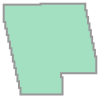

In [ ]:
merged_extent

In [ ]:
# get center of bursts
centroid = merged_extent.centroid
center_coordinate = Point(centroid.x, centroid.y)
print("Center Coordinate (Lat/Lon):", center_coordinate)

Center Coordinate (Lat/Lon): POINT (-118.0019315028894 34.21369195655734)


In [ ]:
# get the tiles that overlap the point
overlapping_tiles = df_mgrs[df_mgrs['geometry'].contains(center_coordinate)]
print(overlapping_tiles)

    mgrs_tile_id  utm_epsg                                            utm_wkt  \
963        11SLT     32611  MULTIPOLYGON(((300000 3800040,300000 3690240,4...   
972        11SMT     32611  MULTIPOLYGON(((399960 3800040,399960 3690240,5...   

                                              geometry  
963  POLYGON ((-119.17378 34.32237, -119.14887 33.3...  
972  POLYGON ((-118.08758 34.33683, -118.07511 33.3...  


In [ ]:
# Filter tiles that overlap the polygon
overlapping_tiles = df_mgrs[df_mgrs['geometry'].intersects(merged_extent)]
print(overlapping_tiles)

    mgrs_tile_id  utm_epsg                                            utm_wkt  \
956        11SKU     32611  MULTIPOLYGON(((199980 3900000,199980 3790200,3...   
957        11SKV     32611  MULTIPOLYGON(((199980 4000020,199980 3890220,3...   
962        11SLS     32611  MULTIPOLYGON(((300000 3700020,300000 3590220,4...   
963        11SLT     32611  MULTIPOLYGON(((300000 3800040,300000 3690240,4...   
964        11SLU     32611  MULTIPOLYGON(((300000 3900000,300000 3790200,4...   
965        11SLV     32611  MULTIPOLYGON(((300000 4000020,300000 3890220,4...   
971        11SMS     32611  MULTIPOLYGON(((399960 3700020,399960 3590220,5...   
972        11SMT     32611  MULTIPOLYGON(((399960 3800040,399960 3690240,5...   
973        11SMU     32611  MULTIPOLYGON(((399960 3900000,399960 3790200,5...   
974        11SMV     32611  MULTIPOLYGON(((399960 4000020,399960 3890220,5...   
981        11SNT     32611  MULTIPOLYGON(((499980 3800040,499980 3690240,6...   
982        11SNU     32611  

/tmp/ipykernel_179151/4028252391.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


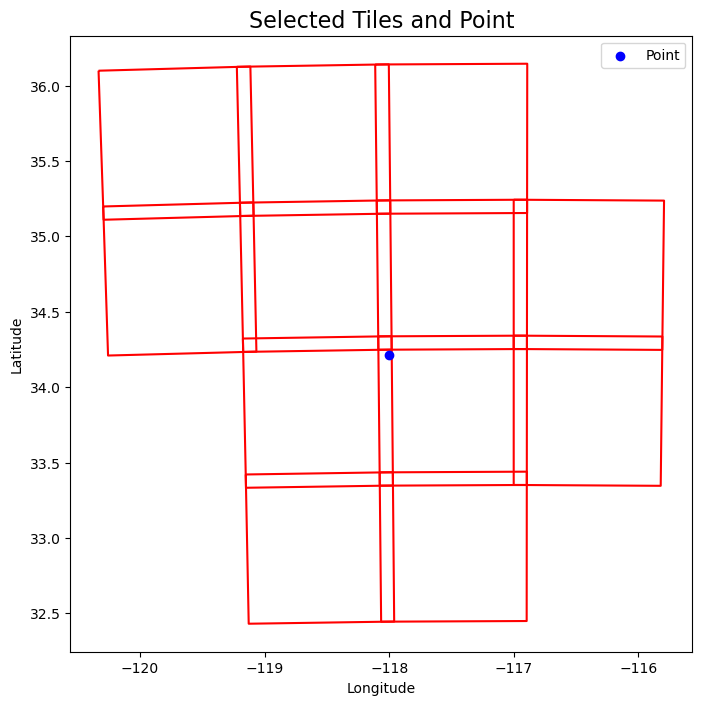

In [14]:
# Plot the GeoDataFrame tiles and highlight overlapping tiles
fig, ax = plt.subplots(figsize=(10, 8))
# Plot overlapping tiles
overlapping_tiles.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1.5, label='Overlapping Tiles')
# Plot the point
ax.scatter(center_coordinate.x, center_coordinate.y, color='blue', label='Point', zorder=5)
# Add title and legend
plt.title('Selected Tiles and Point', fontsize=16)
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

/tmp/ipykernel_179151/2977698758.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(overlapping_tiles.geometry.centroid.x,
/tmp/ipykernel_179151/2977698758.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlapping_tiles.geometry.centroid.y,
/tmp/ipykernel_179151/2977698758.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left')
/tmp/ipykernel_179151/2977698758.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is cal

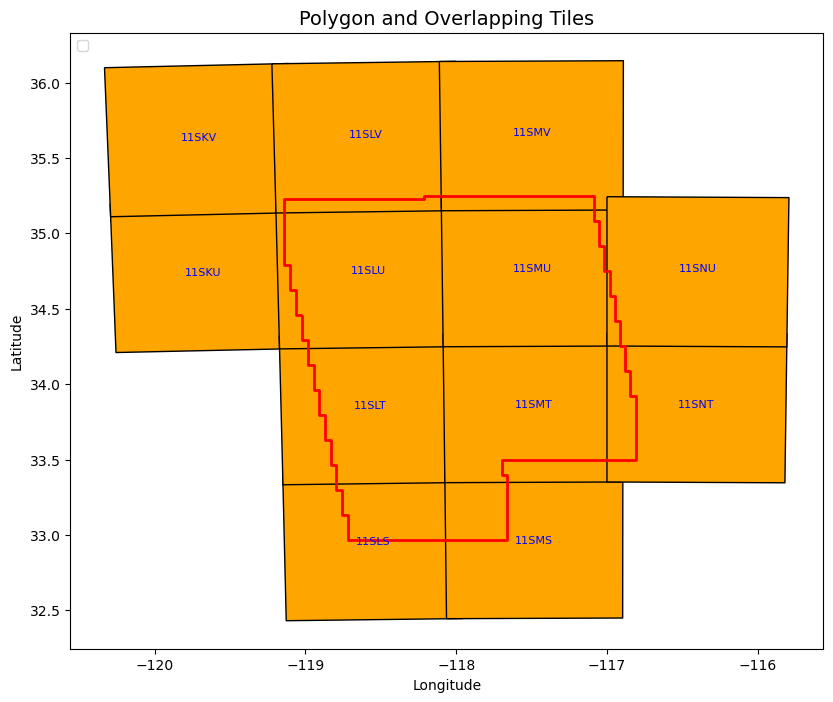

In [15]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
# Highlight overlapping tiles in a different color
overlapping_tiles.plot(ax=ax, color='orange', edgecolor='black', label='Overlapping Tiles')
# Plot the polygon
gpd.GeoSeries([merged_extent]).plot(ax=ax, color='none', edgecolor='red', linewidth=2, label='Polygon')
# Add tile labels (tile_id)
for x, y, label in zip(overlapping_tiles.geometry.centroid.x, 
                       overlapping_tiles.geometry.centroid.y, 
                       overlapping_tiles['mgrs_tile_id']):
    ax.text(x, y, label, fontsize=8, ha='center', color='blue')
# Add legend
ax.legend(loc='upper left')

# Set titles and labels
ax.set_title('Polygon and Overlapping Tiles', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

In [16]:
# create a dataframe with the burst information from the metrics 
available_bursts = [{'burst_id': p.parent.stem, 
                 'f_path': str(p),
                 'acq_timestamp': pd.to_datetime(p.stem.split('_')[2])} for p in metric_burst_paths if '.tif' in p.name]
available_bursts[:3]

[{'burst_id': 'T064-135514-IW1',
  'f_path': 'out/los-angeles-fire/metrics/track64/T064-135514-IW1/transformer_T064-135514-IW1_2025-01-09.tif',
  'acq_timestamp': Timestamp('2025-01-09 00:00:00')},
 {'burst_id': 'T064-135515-IW1',
  'f_path': 'out/los-angeles-fire/metrics/track64/T064-135515-IW1/transformer_T064-135515-IW1_2025-01-09.tif',
  'acq_timestamp': Timestamp('2025-01-09 00:00:00')},
 {'burst_id': 'T064-135516-IW1',
  'f_path': 'out/los-angeles-fire/metrics/track64/T064-135516-IW1/transformer_T064-135516-IW1_2025-01-09.tif',
  'acq_timestamp': Timestamp('2025-01-09 00:00:00')}]

In [17]:
df_metric_bursts = pd.DataFrame(available_bursts)
df_metric_bursts['date_str'] = df_metric_bursts.acq_timestamp.dt.date.astype(str)
df_metric_bursts.head()

,burst_id,f_path,acq_timestamp,date_str
0,T064-135514-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09
1,T064-135515-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09
2,T064-135516-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09
3,T064-135516-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09
4,T064-135517-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09


In [18]:
# assign the mgrs tile to the burst. 


In [19]:
# Merge df_metric_bursts with df_burst on matching burst_id and jpl_burst_id
df_metric_bursts_with_jpl = df_metric_bursts.merge(
    df_burst[['jpl_burst_id', 'geometry']],  # Select the relevant columns from df_burst
    left_on='burst_id',  # Merge on 'burst_id' in df_metric_bursts
    right_on='jpl_burst_id',  # Merge on 'jpl_burst_id' in df_burst
    how='left'  # Use a left join to keep all rows from df_metric_bursts
)


In [20]:
print(len(df_metric_bursts_with_jpl))
df_metric_bursts_with_jpl.head()

21


,burst_id,f_path,acq_timestamp,date_str,jpl_burst_id,geometry
0,T064-135514-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135514-IW1,"POLYGON ((-118.62403 33.01064, -117.71207 33.1..."
1,T064-135515-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135515-IW1,"POLYGON ((-118.66236 33.17675, -117.74859 33.3..."
2,T064-135516-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135516-IW1,"POLYGON ((-118.70077 33.34286, -117.78516 33.4..."
3,T064-135516-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135516-IW2,"POLYGON ((-117.82791 33.54487, -116.86420 33.6..."
4,T064-135517-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135517-IW1,"POLYGON ((-118.73925 33.50896, -117.82179 33.6..."


In [21]:
# convert to geodataframe
df_metric_bursts_with_jpl = gpd.GeoDataFrame(df_metric_bursts_with_jpl, geometry='geometry')

In [22]:
# Select a tile to merge
SELECTED_TILE = '11SMU'

In [23]:
# Step 1: Find the geometry of the specific tile
tile_geometry = overlapping_tiles[overlapping_tiles['mgrs_tile_id'] == SELECTED_TILE].geometry.iloc[0]

# Step 2: Perform a spatial join to find bursts overlapping with this tile
overlapping_bursts = gpd.sjoin(
    df_metric_bursts_with_jpl,
    gpd.GeoDataFrame(geometry=[tile_geometry], crs=overlapping_tiles.crs),
    how='inner',
    predicate='intersects'
)

# Step 3: Get the list of burst_ids that overlap with the tile
overlapping_burst_ids = overlapping_bursts['burst_id'].tolist()

# Inspect the result
print(overlapping_burst_ids)

['T064-135519-IW2', 'T064-135520-IW1', 'T064-135520-IW2', 'T064-135521-IW1', 'T064-135521-IW2', 'T064-135522-IW1', 'T064-135522-IW2', 'T064-135523-IW1', 'T064-135523-IW2', 'T064-135524-IW1', 'T064-135524-IW2']


In [24]:
bursts2megre = df_metric_bursts_with_jpl[df_metric_bursts_with_jpl['burst_id'].isin(overlapping_burst_ids)]
print(len(bursts2megre))
bursts2megre

11


,burst_id,f_path,acq_timestamp,date_str,jpl_burst_id,geometry
9,T064-135519-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135519-IW2,"POLYGON ((-117.93820 34.04307, -116.96863 34.1..."
10,T064-135520-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135520-IW1,"POLYGON ((-118.85147 34.00777, -117.92922 34.1..."
11,T064-135520-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135520-IW2,"POLYGON ((-117.97221 34.20954, -117.00154 34.3..."
12,T064-135521-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135521-IW1,"POLYGON ((-118.89023 34.17383, -117.96608 34.3..."
13,T064-135521-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135521-IW2,"POLYGON ((-118.00915 34.37558, -117.03647 34.5..."
14,T064-135522-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135522-IW1,"POLYGON ((-118.92907 34.33988, -118.00299 34.4..."
15,T064-135522-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135522-IW2,"POLYGON ((-118.04614 34.54161, -117.07145 34.6..."
16,T064-135523-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135523-IW1,"POLYGON ((-118.96799 34.50592, -118.03997 34.6..."
17,T064-135523-IW2,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135523-IW2,"POLYGON ((-118.08320 34.70764, -117.10648 34.8..."
18,T064-135524-IW1,out/los-angeles-fire/metrics/track64/T064-1355...,2025-01-09,2025-01-09,T064-135524-IW1,"POLYGON ((-119.00699 34.67196, -118.07701 34.8..."


In [25]:
burst2merge_list = bursts2megre['f_path'].tolist()
# Convert each path to a PosixPath object
burst2merge_list = [Path(path).as_posix() for path in burst2merge_list]
# Now, wrap them into PosixPath objects
burst2merge_list = [Path(path) for path in burst2merge_list]
burst2merge_list

[PosixPath('out/los-angeles-fire/metrics/track64/T064-135519-IW2/transformer_T064-135519-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135520-IW1/transformer_T064-135520-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135520-IW2/transformer_T064-135520-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135521-IW1/transformer_T064-135521-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135521-IW2/transformer_T064-135521-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135522-IW1/transformer_T064-135522-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135522-IW2/transformer_T064-135522-IW2_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135523-IW1/transformer_T064-135523-IW1_2025-01-09.tif'),
 PosixPath('out/los-angeles-fire/metrics/track64/T064-135523-IW2/transformer_T064-135523-IW2_2025-01-09.tif'),
 

In [26]:
# Reproject tifs to the same CRS
metric_crs_dir = Path('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test')
crs_ref = 'EPSG:32611'

In [27]:
def reproject_to_shared_crs_and_serialize(path: Path, ref_crs: CRS):
    with rasterio.open(path) as ds:
        X = ds.read(1)
        p = ds.profile

    out_path = metric_crs_dir / path.name
    
    if p['crs'] == ref_crs:
        shutil.copy(path, out_path)
        return out_path
    else:
        p_crs = reproject_profile_to_new_crs(p_src, ref_crs)
        X_r, p_r = reproject_arr_to_match_profile(X, p, p_crs)
        with rasterio.open(out_path, 'w', **p_r) as ds:
            ds.write(X_r)
    return out_path

In [28]:
reproject_to_shared_crs_and_serialize_p = lambda path: reproject_to_shared_crs_and_serialize(path, crs_ref)
metric_paths_crs = list(map(reproject_to_shared_crs_and_serialize_p, tqdm(burst2merge_list)))
metric_paths_crs[:3]

 18%|█▊        | 2/11 [00:00<00:02,  4.07it/s]

100%|██████████| 11/11 [00:01<00:00,  6.62it/s]


[PosixPath('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/transformer_T064-135519-IW2_2025-01-09.tif'),
 PosixPath('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/transformer_T064-135520-IW1_2025-01-09.tif'),
 PosixPath('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/transformer_T064-135520-IW2_2025-01-09.tif')]

In [48]:
# This works, basically same as charlie 
from rasterio.merge import merge

# Merge the raster images with averaging in the overlapping regions
X_m, t_m = merge(metric_paths_crs, method='first')

# Get the profile of the first image
with rasterio.open(metric_paths_crs[0]) as ds:
    p_met = ds.profile

# Update the transform and dimensions to match the merged data
p_met['transform'] = t_m
p_met['height'], p_met['width'] = X_m.shape[-2:]

# Extract the track number and date from the filename
tokens = metric_paths_crs[0].stem.split('_')
track_num_token = tokens[1].split("-")[0]
date_token = tokens[2]

# Write the output to a new file
with rasterio.open(f'out/los-angeles-fire/merge_test/merged_output_{track_num_token}_{tokens[2]}.tif', 'w', **p_met) as ds:
    ds.write(X_m)

#### Merge with average

In [57]:
# Function to merge rasters with averaging in overlapping areas
def merge_with_averaging(raster_paths, output_path):
    """
    Merge the raster images with averaging in the overlapping regions. 
    """
    datasets = [rasterio.open(path) for path in raster_paths]
    # Merge the datasets by sum and count
    merged_data, transform = merge(datasets, method='sum')
    count_data, _ = merge(datasets, method='count')
    # Calculate the average for overlapping region
    averaged_data = np.divide(merged_data, count_data, out=np.zeros_like(merged_data), where=count_data > 0)
    # Replace zero values with NaN to mathc the source
    averaged_data[averaged_data == 0] = np.nan

    # Update profile
    profile = datasets[0].profile
    profile.update({
        "height": averaged_data.shape[1],
        "width": averaged_data.shape[2],
        "transform": transform,
    })
    
    # Write merged raster to file
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(averaged_data)
    # Close datasets
    for dataset in datasets:
        dataset.close()

# Out path
output_file = 'out/los-angeles-fire/merge_test/merged_output_test_avg.tif'
# Run
merge_with_averaging(metric_paths_crs, output_file)

#### Merge using masks

In [63]:
from rasterio.transform import from_bounds

# for the case where rasters are not in the same CRS. 
def align_to_common_grid(dataset, target_transform, target_shape):
    """
    Match arrays to target transform.
    """
    # Create an empty array with the target shape
    aligned_data = np.zeros(target_shape, dtype=dataset.dtypes[0])
    
    # Reproject and resample the dataset into the target grid
    rasterio.warp.reproject(
        source=rasterio.band(dataset, 1),
        destination=aligned_data,
        src_transform=dataset.transform,
        dst_transform=target_transform,
        src_crs=dataset.crs,
        dst_crs=dataset.crs, 
        resampling=rasterio.enums.Resampling.bilinear,
    )
    return aligned_data

def calculate_bounds_union(datasets):
    """
    Calculate the union of the bounds of all input datasets.
    """
    xmin = min(ds.bounds.left for ds in datasets)
    ymin = min(ds.bounds.bottom for ds in datasets)
    xmax = max(ds.bounds.right for ds in datasets)
    ymax = max(ds.bounds.top for ds in datasets)
    return xmin, ymin, xmax, ymax

def merge_with_masks(raster_paths, output_path):
    """
    Merge rasters using masks and averaging. 
    """
    # Open datasets
    datasets = [rasterio.open(path) for path in raster_paths]
    # Calculate the common bounding box and resolution
    bounds = calculate_bounds_union(datasets)
    resolution = datasets[0].res 
    # Create a common transform and calculate the output shape
    target_transform = from_bounds(
        *bounds,
        width=int((bounds[2] - bounds[0]) / resolution[0]),
        height=int((bounds[3] - bounds[1]) / resolution[1]),
    )
    target_shape = (
        int((bounds[3] - bounds[1]) / resolution[1]),
        int((bounds[2] - bounds[0]) / resolution[0]),
    )
    
    # Initialize arrays for merged data 
    merged_data = np.zeros(target_shape, dtype=np.float32)
    overlap_count = np.zeros(target_shape, dtype=np.int32)
    
    for dataset in datasets:
        # Align each dataset to the common grid (probably not necesary)
        aligned_data = align_to_common_grid(dataset, target_transform, target_shape)
        mask = aligned_data > 0  # mask of valid data
        # Add data to the merged array and update the overlap count
        merged_data += np.where(mask, aligned_data, 0)
        overlap_count += mask.astype(np.int32)
    
    # Calculate average
    merged_data = np.divide(merged_data, overlap_count, out=np.zeros_like(merged_data), where=overlap_count > 0)
    # Update profile
    profile = datasets[0].profile
    profile.update({
        "height": target_shape[0],
        "width": target_shape[1],
        "transform": target_transform,
        "dtype": 'float32',
    })
    
    # Write merged raster
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(merged_data, 1)
    # Close datasets
    for dataset in datasets:
        dataset.close()

# Paths to input
output_file = 'out/los-angeles-fire/merge_test/merged_output_test_avg_masks.tif'
# Merge rasters
merge_with_masks(metric_paths_crs, output_file)


#### Merge with weighted average

In [34]:
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from scipy.ndimage import distance_transform_edt

def align_to_common_grid(dataset, target_transform, target_shape):
    """
    Match arrays to target transform.
    """
    # Create empty array with target shape
    aligned_data = np.full(target_shape, np.nan, dtype=np.float32)
    # Reproject and resample into aligned grid
    reproject(
        source=rasterio.band(dataset, 1),
        destination=aligned_data,
        src_transform=dataset.transform,
        dst_transform=target_transform,
        src_crs=dataset.crs,
        dst_crs=dataset.crs,
        resampling=Resampling.bilinear,
    )
    return aligned_data

def calculate_bounds_union(datasets):
    """
    Calculate the union of the bounds of all input datasets.
    """
    xmin = min(ds.bounds.left for ds in datasets)
    ymin = min(ds.bounds.bottom for ds in datasets)
    xmax = max(ds.bounds.right for ds in datasets)
    ymax = max(ds.bounds.top for ds in datasets)
    return xmin, ymin, xmax, ymax

def merge_weighted_average(raster_paths, output_path):
    """ 
    Merge rasters using weighted average.
    """
    # Open datasets
    datasets = [rasterio.open(path) for path in raster_paths]
    # Calculate the common bounding box and resolution
    bounds = calculate_bounds_union(datasets)
    resolution = datasets[0].res
    # Create a common transform and calculate the output shape
    target_transform = from_bounds(
        *bounds,
        width=int((bounds[2] - bounds[0]) / resolution[0]),
        height=int((bounds[3] - bounds[1]) / resolution[1]),
    )
    target_shape = (
        int((bounds[3] - bounds[1]) / resolution[1]),
        int((bounds[2] - bounds[0]) / resolution[0]),
    )
    # Initialize arrays for merged data and weights
    merged_data = np.zeros(target_shape, dtype=np.float32)
    weight_sum = np.zeros(target_shape, dtype=np.float32)

    for dataset in datasets:
        # Align data to common grid
        aligned_data = align_to_common_grid(dataset, target_transform, target_shape)
        mask = ~np.isnan(aligned_data)  # Mask of valid data
        filled_data = np.nan_to_num(aligned_data, nan=0)  # Replace NaNs with 0
        # Compute weights using distance transform
        weights = distance_transform_edt(~mask).astype(np.float32)
        weights[mask] = 1.0 / (weights[mask] + 1e-6)  # Invert distance to create weights
        # Accumulate weighted data and weights
        merged_data += filled_data * weights
        weight_sum += weights

    # Calculate weighted average
    merged_data = np.divide(
        merged_data, weight_sum, out=np.zeros_like(merged_data), where=weight_sum > 0
    )
    # Replace zero values with NaN to match source format
    merged_data[merged_data == 0] = np.nan

    # Update the profile
    profile = datasets[0].profile
    profile.update({
        "height": target_shape[0],
        "width": target_shape[1],
        "transform": target_transform,
        "dtype": 'float32',
    })

    # Write the merged raster to file
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(merged_data, 1)
    # Close all datasets
    for dataset in datasets:
        dataset.close()

# Output path
output_file = "out/los-angeles-fire/merge_test/merged_output_test_avg_weighted.tif"
# Run
merge_weighted_average(metric_paths_crs, output_file)

#### Erode raster
This function will also erode the inner burst nans 

In [39]:
from scipy.ndimage import binary_erosion

def erode_raster(input_path, output_path, erosion_pixels=5):
    with rasterio.open(input_path) as src:
        raster_data = src.read(1)
        nodata = src.nodata
        profile = src.profile

        # Identify valid data
        valid_data_mask = ~np.isnan(raster_data)  # Invert to get valid region
        # Apply erosion to valid data mask
        structure = np.ones((erosion_pixels, erosion_pixels), dtype=bool)
        eroded_valid_mask = binary_erosion(valid_data_mask, structure=structure)
        # Create the eroded raster and preserving NaN as NoData
        eroded_data = np.where(eroded_valid_mask, raster_data, np.nan)
        # Update the raster profile
        profile.update({
            "dtype": "float32", 
            "nodata": np.nan  
        })

        # Write raster to file
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(eroded_data, 1)

    return output_path, profile

# Run
input_raster = metric_paths_crs[0]
output_raster = "out/los-angeles-fire/merge_test/eroded_burst.tif"
out_path, out_profile = erode_raster(input_raster, output_raster, erosion_pixels=10)
print(f"Input Raster Path: {input_raster}")
print(f"Output Raster Path: {out_path}")
print(f"Raster Profile: {out_profile}")

Input Raster Path: /u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/transformer_T064-135519-IW2_2025-01-09.tif
Output Raster Path: out/los-angeles-fire/merge_test/eroded_burst.tif
Raster Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 3428, 'height': 1548, 'count': 1, 'crs': CRS.from_epsg(32611), 'transform': Affine(30.0, 0.0, 405060.0,
       0.0, -30.0, 3808740.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}


#### Erode raster and do not erode inner NaN's 
This function works fine 

In [52]:
from scipy.ndimage import binary_erosion, binary_fill_holes

def erode_raster_filled(input_path, output_path, erosion_pixels=5):
    with rasterio.open(input_path) as src:
        raster_data = src.read(1) 
        nodata = src.nodata
        profile = src.profile
        # Identify valid data
        valid_data_mask = ~np.isnan(raster_data)
        # Fill holes in the valid data mask
        filled_valid_mask = binary_fill_holes(valid_data_mask)
        # Apply erosion to the filled mask
        structure = np.ones((erosion_pixels, erosion_pixels), dtype=bool)
        eroded_mask = binary_erosion(filled_valid_mask, structure=structure)
        # Create the eroded raster and preserving NaN as NoData
        eroded_data = np.where(eroded_mask, raster_data, np.nan)
        # Update the raster profile
        profile.update({
            "dtype": "float32",
            "nodata": np.nan
        })
        # Write raster to file
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(eroded_data, 1)

    return output_path, profile

# Run
input_raster = metric_paths_crs[0]
output_raster = "out/los-angeles-fire/merge_test/eroded_filled.tif"
out_path, out_profile = erode_raster_filled(input_raster, output_raster, erosion_pixels=10)
print(f"Input Raster Path: {input_raster}")
print(f"Output Raster Path: {out_path}")
print(f"Raster Profile: {out_profile}")

Input Raster Path: /u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/transformer_T064-135519-IW2_2025-01-09.tif
Output Raster Path: out/los-angeles-fire/merge_test/eroded_filled.tif
Raster Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 3428, 'height': 1548, 'count': 1, 'crs': CRS.from_epsg(32611), 'transform': Affine(30.0, 0.0, 405060.0,
       0.0, -30.0, 3808740.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}


#### Erode using labels
This function creates labels for valid data as well as for NaN regions. It uses the small NaN to fill gaps in the valid data and thus only erode the edges. 

In [29]:
from scipy.ndimage import binary_erosion
from skimage.measure import label as labeler, regionprops

def erode_raster_with_gap_filling(input_path, output_path, erosion_pixels=5, min_area=200):
    """
    Erode a raster while filling small NoData gaps based on a size threshold.
    Args:
        erosion_pixels (int): Number of pixels for the erosion kernel size.
        min_area (int): Minimum size (in pixels) of NoData regions to fill.
    """
    with rasterio.open(input_path) as src:
        raster_data = src.read(1)
        nodata = src.nodata
        profile = src.profile
        # Identify valid data and NoData masks
        valid_data_mask = ~np.isnan(raster_data)
        nodata_mask = np.isnan(raster_data)
        # Label contiguous NoData regions
        labeled_nodata = labeler(nodata_mask, connectivity=1, background=0)
        nodata_props = regionprops(labeled_nodata)
        # Identify small NoData regions to fill
        small_nodata_regions = np.isin(
            labeled_nodata,
            [prop.label for prop in nodata_props if prop.area <= min_area]
        )
        # Update the valid data mask by filling small NoData regions
        filled_valid_data_mask = valid_data_mask | small_nodata_regions
        # Apply erosion updated valid data mask
        structure = np.ones((erosion_pixels, erosion_pixels), dtype=bool)
        eroded_valid_mask = binary_erosion(filled_valid_data_mask, structure=structure)
        # Create the eroded raster
        eroded_data = np.where(eroded_valid_mask, raster_data, np.nan)
        # Update the raster profile
        profile.update({
            "dtype": "float32",
            "nodata": np.nan
        })
        # Write raster to file
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(eroded_data, 1)

    return output_path, profile

# Run function
input_raster = metric_paths_crs[0] 
out_name = 'eroded_' + input_raster.name
output_raster = input_raster.with_name(out_name)
out_path, out_profile = erode_raster_with_gap_filling(
    input_raster,
    output_raster,
    erosion_pixels=10,
    min_area=200  # Minimum area of NoData regions to fill
)
print(f"Input Raster Path: {input_raster}")
print(f"Output Raster Path: {out_path}")
print(f"Raster Profile: {out_profile}")

Input Raster Path: /u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/transformer_T064-135519-IW2_2025-01-09.tif
Output Raster Path: /u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/eroded_transformer_T064-135519-IW2_2025-01-09.tif
Raster Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 3428, 'height': 1548, 'count': 1, 'crs': CRS.from_epsg(32611), 'transform': Affine(30.0, 0.0, 405060.0,
       0.0, -30.0, 3808740.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}


#### Erode a group of burst 

In [30]:
def run_erosion(input_raster):
    out_name = 'eroded_' + input_raster.name
    output_raster = input_raster.with_name(out_name)
    out_path, out_profile = erode_raster_with_gap_filling(
        input_raster,
        output_raster,
        erosion_pixels=10,
        min_area=200 
    )
    return out_path  

# Run function
eroded_paths = list(map(run_erosion, tqdm(metric_paths_crs)))
print(eroded_paths[:3])

100%|██████████| 11/11 [00:05<00:00,  2.13it/s]

[PosixPath('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/eroded_transformer_T064-135519-IW2_2025-01-09.tif'), PosixPath('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/eroded_transformer_T064-135520-IW1_2025-01-09.tif'), PosixPath('/u/aurora-r0/cabrera/opera_dist/out/los-angeles-fire/merge_test/eroded_transformer_T064-135520-IW2_2025-01-09.tif')]


### Merge eroded 

In [35]:
# Output path
output_file = "out/los-angeles-fire/merge_test/merged_eroded_transformer_avg_weighted.tif"
# Run
merge_weighted_average(eroded_paths, output_file)